In [3]:
import minari
from gymnasium_robotics.envs.maze.maze_v4 import MazeEnv

dataset = minari.load_dataset('D4RL/pointmaze/large-v2', download=True)
# env  = dataset.recover_environment()
print(type(dataset))
print("Observation space:", dataset.observation_space)
print("Action space:", dataset.action_space)
print("Total episodes:", dataset.total_episodes)
print("Total steps:", dataset.total_steps)

<class 'minari.dataset.minari_dataset.MinariDataset'>
Observation space: Dict('achieved_goal': Box(-inf, inf, (2,), float64), 'desired_goal': Box(-inf, inf, (2,), float64), 'observation': Box(-inf, inf, (4,), float64))
Action space: Box(-1.0, 1.0, (2,), float32)
Total episodes: 3360
Total steps: 1000000


Processed 500/3360 episodes...
Processed 1000/3360 episodes...
Processed 1500/3360 episodes...
Processed 2000/3360 episodes...
Processed 2500/3360 episodes...
Processed 3000/3360 episodes...
Collected data for 3360 episodes


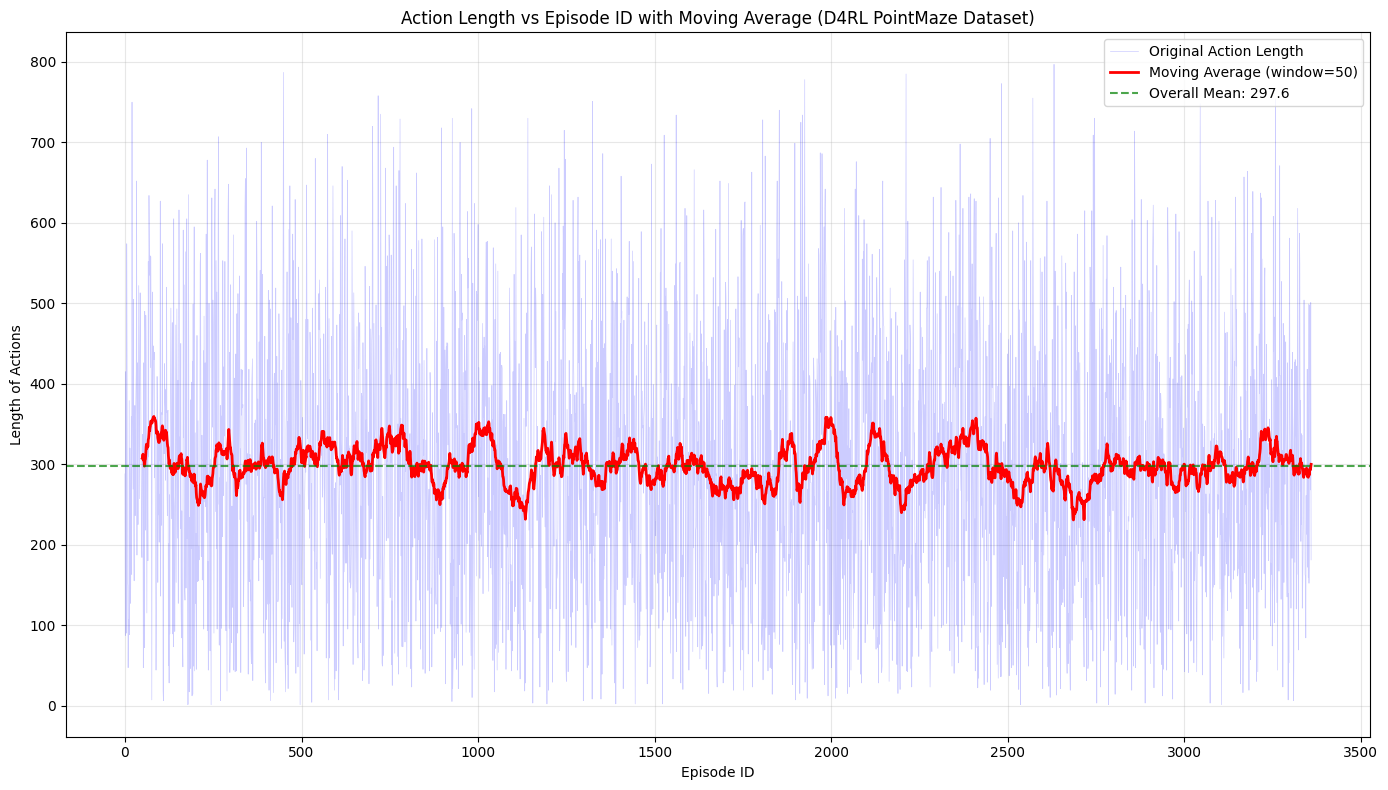


Action Length Statistics:
- Total episodes: 3360
- Min action length: 1
- Max action length: 797
- Mean action length: 297.62
- Moving average window size: 50
- Moving average range: 230.7 - 359.2


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Collect episode IDs and action lengths
episode_ids = []
action_lengths = []

print("Collecting action lengths for all episodes...")

for i, episode in enumerate(dataset.iterate_episodes()):
    episode_ids.append(i)
    action_lengths.append(len(episode.actions))
    
    # Print progress every 500 episodes
    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{dataset.total_episodes} episodes...")

print(f"Collected data for {len(episode_ids)} episodes")

# Calculate moving average
def moving_average(data, window_size):
    """Calculate moving average with given window size"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Different window sizes for moving averages
window_size = 50  # Adjust this to make it more or less smooth
ma_action_lengths = moving_average(action_lengths, window_size)
ma_episode_ids = episode_ids[window_size-1:]  # Adjust episode IDs for moving average

# Create the plot
plt.figure(figsize=(14, 8))

# Plot original data (more transparent)
plt.plot(episode_ids, action_lengths, 'b-', alpha=0.2, linewidth=0.5, label='Original Action Length')

# Plot moving average (more prominent)
plt.plot(ma_episode_ids, ma_action_lengths, 'r-', linewidth=2, label=f'Moving Average (window={window_size})')

plt.xlabel('Episode ID')
plt.ylabel('Length of Actions')
plt.title(f'Action Length vs Episode ID with Moving Average (D4RL PointMaze Dataset)')
plt.grid(True, alpha=0.3)

# Add statistics
mean_length = sum(action_lengths) / len(action_lengths)
plt.axhline(y=mean_length, color='g', linestyle='--', alpha=0.7, 
           label=f'Overall Mean: {mean_length:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print(f"\nAction Length Statistics:")
print(f"- Total episodes: {len(action_lengths)}")
print(f"- Min action length: {min(action_lengths)}")
print(f"- Max action length: {max(action_lengths)}")
print(f"- Mean action length: {mean_length:.2f}")
print(f"- Moving average window size: {window_size}")
print(f"- Moving average range: {min(ma_action_lengths):.1f} - {max(ma_action_lengths):.1f}")

In [4]:
import gymnasium as gym
import gymnasium_robotics

# Register robotics environments
gym.register_envs(gymnasium_robotics)

# Create PointMaze environment directly
print("Creating PointMaze environment...")
env = gym.make("PointMaze_Large-v3")

print(f"Environment: {env}")
print(f"Environment ID: {env.spec.id}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Reset and explore the environment
print("\n" + "="*50)
print("EXPLORING POINTMAZE ENVIRONMENT")
print("="*50)

# Reset environment
obs, info = env.reset()
print(f"\nInitial reset:")
print(f"- Observation keys: {obs.keys()}")
for key, value in obs.items():
    print(f"  {key}: {value}")
print(f"- Info: {info}")

# Take multiple steps to see the environment behavior
print(f"\nTaking 10 random steps...")
for step in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    print(f"\nStep {step + 1}:")
    print(f"- Action: {action}")
    print(f"- Agent position: {obs['achieved_goal']}")
    print(f"- Goal position: {obs['desired_goal']}")
    print(f"- Reward: {reward}")
    print(f"- Terminated: {terminated}, Truncated: {truncated}")
    print(f"- Success: {info.get('success', 'N/A')}")
    
    if terminated or truncated:
        print("Episode ended!")
        obs, info = env.reset()
        print("Environment reset.")
        break

# Explore environment properties
print(f"\n" + "="*50)
print("ENVIRONMENT PROPERTIES")
print("="*50)

# Check if environment has maze layout or other properties
if hasattr(env, 'maze'):
    print(f"Maze layout: {env.maze}")
if hasattr(env, 'maze_map'):
    print(f"Maze map shape: {env.maze_map.shape}")
if hasattr(env, 'goal_cell'):
    print(f"Goal cell: {env.goal_cell}")

# Check unwrapped environment for more details
unwrapped_env = env.unwrapped
print(f"Unwrapped environment type: {type(unwrapped_env)}")
print(f"Unwrapped environment attributes: {[attr for attr in dir(unwrapped_env) if not attr.startswith('_')]}")

print("\nPointMaze exploration complete!")

Creating PointMaze environment...
Environment: <TimeLimit<OrderEnforcing<PassiveEnvChecker<PointMazeEnv<PointMaze_Large-v3>>>>>
Environment ID: PointMaze_Large-v3
Observation space: Dict('achieved_goal': Box(-inf, inf, (2,), float64), 'desired_goal': Box(-inf, inf, (2,), float64), 'observation': Box(-inf, inf, (4,), float64))
Action space: Box(-1.0, 1.0, (2,), float32)

EXPLORING POINTMAZE ENVIRONMENT

Initial reset:
- Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
  observation: [2.6356463 3.1476035 0.        0.       ]
  achieved_goal: [2.6356463 3.1476035]
  desired_goal: [-1.47434408 -3.02958279]
- Info: {'success': False}

Taking 10 random steps...

Step 1:
- Action: [ 0.29922548 -0.36690238]
- Agent position: [2.63635895 3.14672967]
- Goal position: [-1.47434408 -3.02958279]
- Reward: 0.0
- Terminated: False, Truncated: False
- Success: False

Step 2:
- Action: [-0.02256585  0.27265224]
- Agent position: [2.63701615 3.14650729]
- Goal position: [-1.

ADVANCED POINTMAZE ANALYSIS


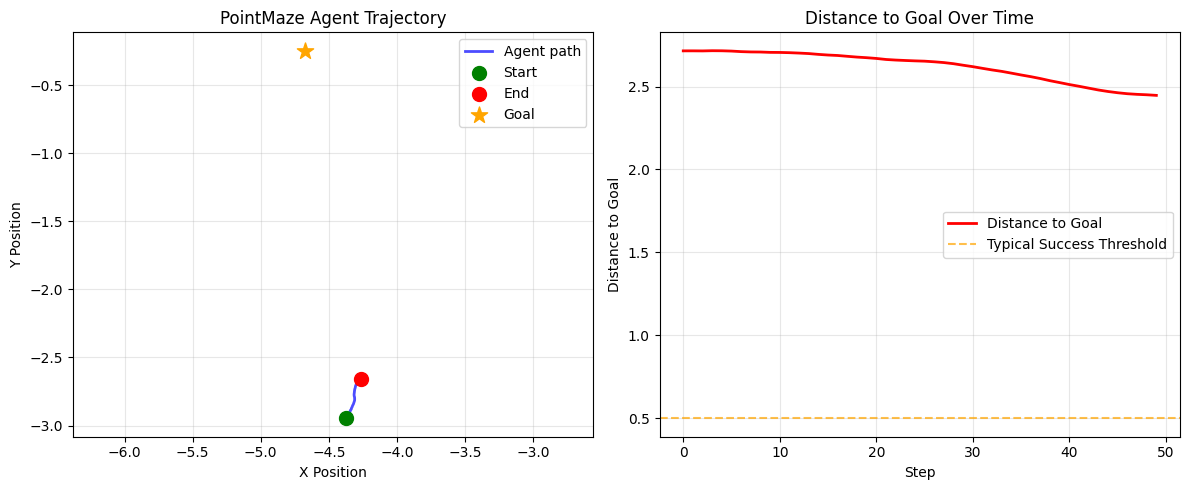


Trajectory Analysis:
- Total steps: 50
- Initial position: [-4.37574122 -2.9469206 ]
- Final position: [-4.26413971 -2.66058788]
- Goal position: [-4.67305473 -0.24822264]
- Initial distance to goal: 2.715
- Final distance to goal: 2.447
- Min distance achieved: 2.447
- Total reward: 0.000
- Average reward per step: 0.000

Environment Bounds Analysis:
- X range: [-4.38, -4.26]
- Y range: [-2.95, -2.66]
- Movement variance X: 0.001
- Movement variance Y: 0.009

This data can be used for RND curiosity analysis!


In [6]:
# Additional PointMaze Analysis and Visualization
import matplotlib.pyplot as plt
import numpy as np

print("ADVANCED POINTMAZE ANALYSIS")
print("="*40)

# Reset environment
env.reset()

# Collect trajectory data
trajectory_positions = []
trajectory_goals = []
trajectory_rewards = []
steps = 50

print(f"Collecting trajectory data for {steps} steps...")

for i in range(steps):
    # Take action (you can change this to different strategies)
    action = env.action_space.sample()  # Random action
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    trajectory_positions.append(obs['achieved_goal'].copy())
    trajectory_goals.append(obs['desired_goal'].copy())
    trajectory_rewards.append(reward)
    
    if terminated or truncated:
        print(f"Episode ended at step {i}")
        break

# Convert to numpy arrays for easier plotting
positions = np.array(trajectory_positions)
goals = np.array(trajectory_goals)
rewards = np.array(trajectory_rewards)

# Create visualization
plt.figure(figsize=(12, 5))

# Plot 1: Agent trajectory
plt.subplot(1, 2, 1)
plt.plot(positions[:, 0], positions[:, 1], 'b-', alpha=0.7, linewidth=2, label='Agent path')
plt.scatter(positions[0, 0], positions[0, 1], color='green', s=100, label='Start', zorder=5)
plt.scatter(positions[-1, 0], positions[-1, 1], color='red', s=100, label='End', zorder=5)
plt.scatter(goals[0, 0], goals[0, 1], color='orange', s=150, marker='*', label='Goal', zorder=5)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('PointMaze Agent Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Distance to goal over time
plt.subplot(1, 2, 2)
distances = np.linalg.norm(positions - goals, axis=1)
plt.plot(distances, 'r-', linewidth=2, label='Distance to Goal')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Typical Success Threshold')
plt.xlabel('Step')
plt.ylabel('Distance to Goal')
plt.title('Distance to Goal Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print analysis
print(f"\nTrajectory Analysis:")
print(f"- Total steps: {len(positions)}")
print(f"- Initial position: {positions[0]}")
print(f"- Final position: {positions[-1]}")
print(f"- Goal position: {goals[0]}")
print(f"- Initial distance to goal: {distances[0]:.3f}")
print(f"- Final distance to goal: {distances[-1]:.3f}")
print(f"- Min distance achieved: {distances.min():.3f}")
print(f"- Total reward: {rewards.sum():.3f}")
print(f"- Average reward per step: {rewards.mean():.3f}")

# Environment bounds analysis
print(f"\nEnvironment Bounds Analysis:")
print(f"- X range: [{positions[:, 0].min():.2f}, {positions[:, 0].max():.2f}]")
print(f"- Y range: [{positions[:, 1].min():.2f}, {positions[:, 1].max():.2f}]")
print(f"- Movement variance X: {positions[:, 0].var():.3f}")
print(f"- Movement variance Y: {positions[:, 1].var():.3f}")

print("\nThis data can be used for RND curiosity analysis!")

In [ ]:
# Find the center coordinates (before noise) of goal and reset positions
import numpy as np
import matplotlib.pyplot as plt

print("ANALYZING CENTER COORDINATES (BEFORE NOISE)")
print("="*50)

# Access the unwrapped environment to get maze information
unwrapped_env = env.unwrapped

# Get maze properties
print("Maze Properties:")
maze_map = unwrapped_env.maze.maze_map
print(f"- Maze map dimensions: {len(maze_map)} x {len(maze_map[0]) if maze_map else 0}")
print(f"- Maze size scaling: {unwrapped_env.maze.maze_size_scaling}")
print(f"- Maze type: {type(unwrapped_env.maze)}")

# Get unique goal and reset locations (before noise)
print(f"\nUnique Goal Locations (centers before noise):")
goal_locations = unwrapped_env.maze.unique_goal_locations
for i, goal_loc in enumerate(goal_locations):
    print(f"  Goal {i}: x={goal_loc[0]:.3f}, y={goal_loc[1]:.3f}")

print(f"\nUnique Reset Locations (centers before noise):")
reset_locations = unwrapped_env.maze.unique_reset_locations
for i, reset_loc in enumerate(reset_locations):
    print(f"  Reset {i}: x={reset_loc[0]:.3f}, y={reset_loc[1]:.3f}")

# Show current goal and reset positions (after noise)
print(f"\nCurrent Episode (after noise applied):")
print(f"- Current goal position: x={unwrapped_env.goal[0]:.3f}, y={unwrapped_env.goal[1]:.3f}")
print(f"- Current reset position: x={unwrapped_env.reset_pos[0]:.3f}, y={unwrapped_env.reset_pos[1]:.3f}")

# Show noise range
print(f"\nNoise Configuration:")
print(f"- Position noise range: ±{unwrapped_env.position_noise_range}")
print(f"- Actual noise applied: ±{unwrapped_env.position_noise_range * unwrapped_env.maze.maze_size_scaling}")

# Reset multiple times to see the pattern
print(f"\nMultiple Resets Analysis (showing centers vs noisy positions):")
print("-" * 60)

for reset_num in range(5):
    # Reset environment
    obs, info = env.reset()
    
    # Find which goal location was selected (closest to current goal)
    distances_to_goals = [np.linalg.norm(unwrapped_env.goal - goal_loc) 
                         for goal_loc in goal_locations]
    selected_goal_idx = np.argmin(distances_to_goals)
    selected_goal_center = goal_locations[selected_goal_idx]
    
    # Find which reset location was selected
    distances_to_resets = [np.linalg.norm(unwrapped_env.reset_pos - reset_loc) 
                          for reset_loc in reset_locations]
    selected_reset_idx = np.argmin(distances_to_resets)
    selected_reset_center = reset_locations[selected_reset_idx]
    
    print(f"\nReset {reset_num + 1}:")
    print(f"  Goal - Center: ({selected_goal_center[0]:.3f}, {selected_goal_center[1]:.3f}) → "
          f"Noisy: ({unwrapped_env.goal[0]:.3f}, {unwrapped_env.goal[1]:.3f})")
    print(f"  Reset - Center: ({selected_reset_center[0]:.3f}, {selected_reset_center[1]:.3f}) → "
          f"Noisy: ({unwrapped_env.reset_pos[0]:.3f}, {unwrapped_env.reset_pos[1]:.3f})")
    
    # Calculate actual noise applied
    goal_noise = unwrapped_env.goal - selected_goal_center
    reset_noise = unwrapped_env.reset_pos - selected_reset_center
    print(f"  Applied noise - Goal: ({goal_noise[0]:.3f}, {goal_noise[1]:.3f}), "
          f"Reset: ({reset_noise[0]:.3f}, {reset_noise[1]:.3f})")

print("\nSummary: The 'center' coordinates are the unique_goal_locations and unique_reset_locations!")

ANALYZING CENTER COORDINATES (BEFORE NOISE)
Maze Properties:
- Maze map dimensions: 9 x 12
- Maze size scaling: 1
- Maze type: <class 'gymnasium_robotics.envs.maze.maze_v4.Maze'>

Unique Goal Locations (centers before noise):
  Goal 0: x=-4.500, y=3.000
  Goal 1: x=-3.500, y=3.000
  Goal 2: x=-2.500, y=3.000
  Goal 3: x=-1.500, y=3.000
  Goal 4: x=0.500, y=3.000
  Goal 5: x=1.500, y=3.000
  Goal 6: x=2.500, y=3.000
  Goal 7: x=3.500, y=3.000
  Goal 8: x=4.500, y=3.000
  Goal 9: x=-4.500, y=2.000
  Goal 10: x=-1.500, y=2.000
  Goal 11: x=0.500, y=2.000
  Goal 12: x=2.500, y=2.000
  Goal 13: x=4.500, y=2.000
  Goal 14: x=-4.500, y=1.000
  Goal 15: x=-3.500, y=1.000
  Goal 16: x=-2.500, y=1.000
  Goal 17: x=-1.500, y=1.000
  Goal 18: x=-0.500, y=1.000
  Goal 19: x=0.500, y=1.000
  Goal 20: x=2.500, y=1.000
  Goal 21: x=3.500, y=1.000
  Goal 22: x=4.500, y=1.000
  Goal 23: x=-4.500, y=0.000
  Goal 24: x=0.500, y=0.000
  Goal 25: x=4.500, y=0.000
  Goal 26: x=-4.500, y=-1.000
  Goal 27: x=-

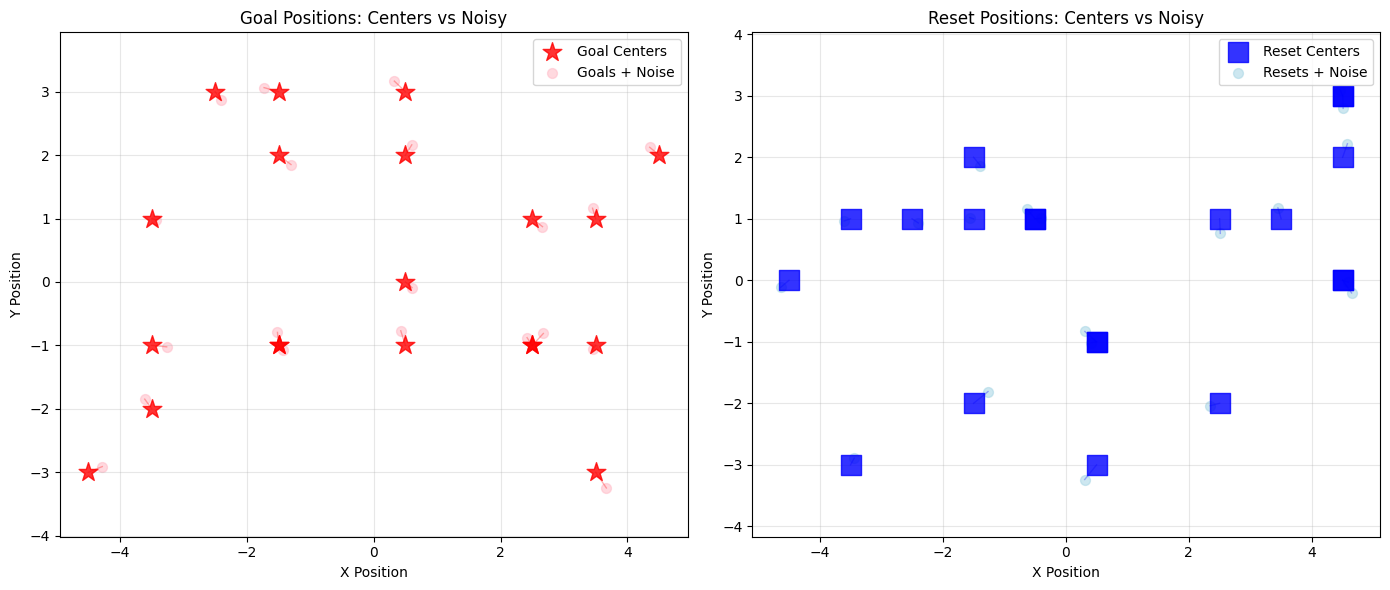


Center Coordinates Summary:
Unique Goal Centers: 18
Unique Reset Centers: 16

All Goal Centers (x, y):
  Goal Center 0: (-4.500, -3.000)
  Goal Center 1: (-3.500, -2.000)
  Goal Center 2: (-3.500, -1.000)
  Goal Center 3: (-3.500, 1.000)
  Goal Center 4: (-2.500, 3.000)
  Goal Center 5: (-1.500, -1.000)
  Goal Center 6: (-1.500, 2.000)
  Goal Center 7: (-1.500, 3.000)
  Goal Center 8: (0.500, -1.000)
  Goal Center 9: (0.500, 0.000)
  Goal Center 10: (0.500, 2.000)
  Goal Center 11: (0.500, 3.000)
  Goal Center 12: (2.500, -1.000)
  Goal Center 13: (2.500, 1.000)
  Goal Center 14: (3.500, -3.000)
  Goal Center 15: (3.500, -1.000)
  Goal Center 16: (3.500, 1.000)
  Goal Center 17: (4.500, 2.000)

All Reset Centers (x, y):
  Reset Center 0: (-4.500, 0.000)
  Reset Center 1: (-3.500, -3.000)
  Reset Center 2: (-3.500, 1.000)
  Reset Center 3: (-2.500, 1.000)
  Reset Center 4: (-1.500, -2.000)
  Reset Center 5: (-1.500, 1.000)
  Reset Center 6: (-1.500, 2.000)
  Reset Center 7: (-0.500, 1.

In [9]:
# Visualize center coordinates vs noisy positions
plt.figure(figsize=(14, 6))

# Collect data for multiple resets
center_goals = []
noisy_goals = []
center_resets = []
noisy_resets = []

print("Collecting data for 20 resets to visualize noise pattern...")

for i in range(20):
    obs, info = env.reset()
    
    # Find selected centers
    distances_to_goals = [np.linalg.norm(unwrapped_env.goal - goal_loc) 
                         for goal_loc in goal_locations]
    selected_goal_center = goal_locations[np.argmin(distances_to_goals)]
    
    distances_to_resets = [np.linalg.norm(unwrapped_env.reset_pos - reset_loc) 
                          for reset_loc in reset_locations]
    selected_reset_center = reset_locations[np.argmin(distances_to_resets)]
    
    center_goals.append(selected_goal_center)
    noisy_goals.append(unwrapped_env.goal.copy())
    center_resets.append(selected_reset_center)
    noisy_resets.append(unwrapped_env.reset_pos.copy())

# Convert to numpy arrays
center_goals = np.array(center_goals)
noisy_goals = np.array(noisy_goals)
center_resets = np.array(center_resets)
noisy_resets = np.array(noisy_resets)

# Plot 1: Goal positions
plt.subplot(1, 2, 1)
plt.scatter(center_goals[:, 0], center_goals[:, 1], 
           c='red', marker='*', s=200, alpha=0.8, label='Goal Centers', zorder=5)
plt.scatter(noisy_goals[:, 0], noisy_goals[:, 1], 
           c='pink', marker='o', s=50, alpha=0.6, label='Goals + Noise')

# Draw lines connecting centers to noisy positions
for i in range(len(center_goals)):
    plt.plot([center_goals[i, 0], noisy_goals[i, 0]], 
            [center_goals[i, 1], noisy_goals[i, 1]], 
            'r-', alpha=0.3, linewidth=1)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Goal Positions: Centers vs Noisy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Reset positions
plt.subplot(1, 2, 2)
plt.scatter(center_resets[:, 0], center_resets[:, 1], 
           c='blue', marker='s', s=200, alpha=0.8, label='Reset Centers', zorder=5)
plt.scatter(noisy_resets[:, 0], noisy_resets[:, 1], 
           c='lightblue', marker='o', s=50, alpha=0.6, label='Resets + Noise')

# Draw lines connecting centers to noisy positions
for i in range(len(center_resets)):
    plt.plot([center_resets[i, 0], noisy_resets[i, 0]], 
            [center_resets[i, 1], noisy_resets[i, 1]], 
            'b-', alpha=0.3, linewidth=1)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Reset Positions: Centers vs Noisy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nCenter Coordinates Summary:")
print(f"Unique Goal Centers: {len(np.unique(center_goals, axis=0))}")
print(f"Unique Reset Centers: {len(np.unique(center_resets, axis=0))}")

unique_goal_centers = np.unique(center_goals, axis=0)
unique_reset_centers = np.unique(center_resets, axis=0)

print(f"\nAll Goal Centers (x, y):")
for i, center in enumerate(unique_goal_centers):
    print(f"  Goal Center {i}: ({center[0]:.3f}, {center[1]:.3f})")

print(f"\nAll Reset Centers (x, y):")
for i, center in enumerate(unique_reset_centers):
    print(f"  Reset Center {i}: ({center[0]:.3f}, {center[1]:.3f})")

print(f"\nNoise Analysis:")
goal_noise_magnitude = np.linalg.norm(noisy_goals - center_goals, axis=1)
reset_noise_magnitude = np.linalg.norm(noisy_resets - center_resets, axis=1)

print(f"Goal noise magnitude - Mean: {goal_noise_magnitude.mean():.3f}, Std: {goal_noise_magnitude.std():.3f}")
print(f"Reset noise magnitude - Mean: {reset_noise_magnitude.mean():.3f}, Std: {reset_noise_magnitude.std():.3f}")
print(f"Max noise range: ±{unwrapped_env.position_noise_range:.3f}")

Processed 500/3360 episodes...
Processed 1000/3360 episodes...
Processed 1500/3360 episodes...
Processed 2000/3360 episodes...
Processed 2500/3360 episodes...
Processed 3000/3360 episodes...
Collected reward data for 3360 episodes


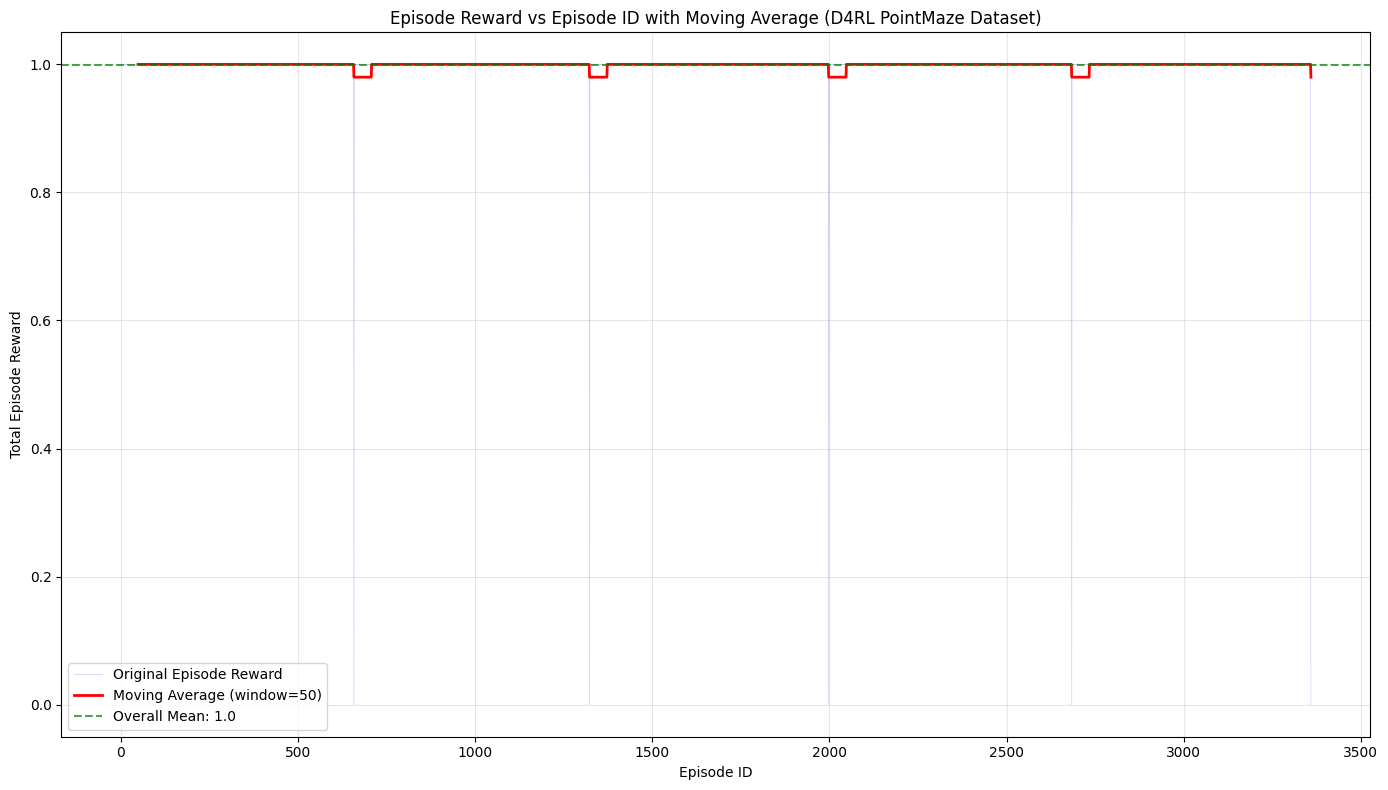


Episode Reward Statistics:
- Total episodes: 3360
- Min episode reward: 0.00
- Max episode reward: 1.00
- Mean episode reward: 1.00
- Std episode reward: 0.04
- Moving average window size: 50
- Moving average range: 1.0 - 1.0

Success Analysis (reward > -5.0):
- Successful episodes: 3360 / 3360 (100.0%)
- Mean reward of successful episodes: 1.00


In [8]:
# Collect episode IDs and total rewards
import matplotlib.pyplot as plt
import numpy as np

episode_ids = []
episode_rewards = []

print("Collecting total rewards for all episodes...")

for i, episode in enumerate(dataset.iterate_episodes()):
    episode_ids.append(i)
    # Sum all rewards in the episode to get total reward
    total_reward = np.sum(episode.rewards)
    episode_rewards.append(total_reward)
    
    # Print progress every 500 episodes
    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{dataset.total_episodes} episodes...")

print(f"Collected reward data for {len(episode_ids)} episodes")

# Calculate moving average
def moving_average(data, window_size):
    """Calculate moving average with given window size"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Different window sizes for moving averages
window_size = 50  # Adjust this to make it more or less smooth
ma_episode_rewards = moving_average(episode_rewards, window_size)
ma_episode_ids = episode_ids[window_size-1:]  # Adjust episode IDs for moving average

# Create the plot
plt.figure(figsize=(14, 8))

# Plot original data (more transparent)
plt.plot(episode_ids, episode_rewards, 'b-', alpha=0.2, linewidth=0.5, label='Original Episode Reward')

# Plot moving average (more prominent)
plt.plot(ma_episode_ids, ma_episode_rewards, 'r-', linewidth=2, label=f'Moving Average (window={window_size})')

plt.xlabel('Episode ID')
plt.ylabel('Total Episode Reward')
plt.title(f'Episode Reward vs Episode ID with Moving Average (D4RL PointMaze Dataset)')
plt.grid(True, alpha=0.3)

# Add statistics
mean_reward = sum(episode_rewards) / len(episode_rewards)
plt.axhline(y=mean_reward, color='g', linestyle='--', alpha=0.7, 
           label=f'Overall Mean: {mean_reward:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print(f"\nEpisode Reward Statistics:")
print(f"- Total episodes: {len(episode_rewards)}")
print(f"- Min episode reward: {min(episode_rewards):.2f}")
print(f"- Max episode reward: {max(episode_rewards):.2f}")
print(f"- Mean episode reward: {mean_reward:.2f}")
print(f"- Std episode reward: {np.std(episode_rewards):.2f}")
print(f"- Moving average window size: {window_size}")
print(f"- Moving average range: {min(ma_episode_rewards):.1f} - {max(ma_episode_rewards):.1f}")

# Additional analysis
success_threshold = -5.0  # Typical success threshold for sparse reward environments
successful_episodes = [r for r in episode_rewards if r > success_threshold]
print(f"\nSuccess Analysis (reward > {success_threshold}):")
print(f"- Successful episodes: {len(successful_episodes)} / {len(episode_rewards)} ({100*len(successful_episodes)/len(episode_rewards):.1f}%)")
if successful_episodes:
    print(f"- Mean reward of successful episodes: {np.mean(successful_episodes):.2f}")

DETAILED REWARD ANALYSIS
Episode Reward Distribution:
- Total episodes analyzed: 3360
- Minimum reward: 0.000000
- Maximum reward: 1.000000
- Mean reward: 0.998512
- Median reward: 1.000000
- Standard deviation: 0.038547

Unique reward values found: 2
First 10 unique rewards: [0. 1.]

Reward value frequency (top 10):
  Reward 1.000000: 3355 episodes (99.9%)
  Reward 0.000000: 5 episodes (0.1%)

Episodes with zero rewards: 5
Zero reward episode indices (first 10): [658, 1323, 1998, 2684, 3359]
Episodes with negative rewards: 0

INDIVIDUAL EPISODE REWARD STRUCTURE ANALYSIS

Episode 0:
  Total episode reward: 1.000000
  Episode length: 288 steps
  Individual step rewards (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Individual step rewards (last 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
  Unique step reward values: [0. 1.]
  Sum verification: 1.000000

Episode 100:
  Total episode reward: 1.000000
  Episode length: 627 steps
  Individual step rewards (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

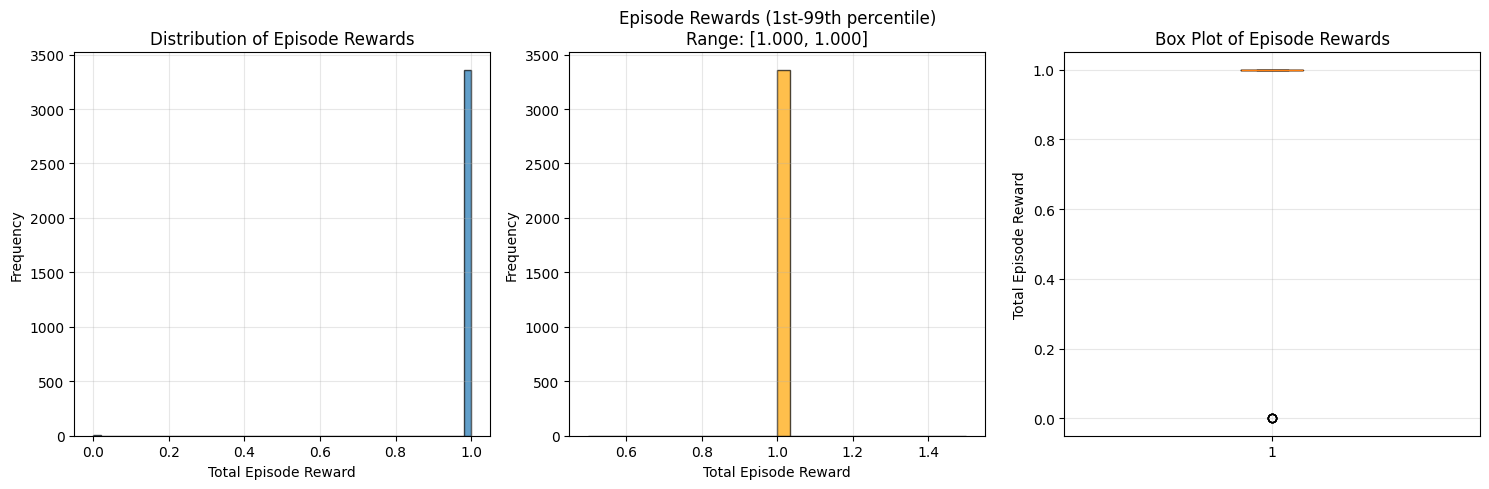


Environment Maximum Reward Analysis:
The maximum observed episode reward in this dataset is: 1.000000
This suggests the theoretical maximum reward per episode is around 1


In [9]:
# Detailed Reward Analysis
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("DETAILED REWARD ANALYSIS")
print("="*50)

# Basic statistics
print(f"Episode Reward Distribution:")
print(f"- Total episodes analyzed: {len(episode_rewards)}")
print(f"- Minimum reward: {min(episode_rewards):.6f}")
print(f"- Maximum reward: {max(episode_rewards):.6f}")
print(f"- Mean reward: {np.mean(episode_rewards):.6f}")
print(f"- Median reward: {np.median(episode_rewards):.6f}")
print(f"- Standard deviation: {np.std(episode_rewards):.6f}")

# Check for unique reward values
unique_rewards = np.unique(episode_rewards)
print(f"\nUnique reward values found: {len(unique_rewards)}")
print("First 10 unique rewards:", unique_rewards[:10])
if len(unique_rewards) > 10:
    print("Last 10 unique rewards:", unique_rewards[-10:])

# Count episodes with specific reward values
reward_counts = Counter(episode_rewards)
print(f"\nReward value frequency (top 10):")
for reward, count in reward_counts.most_common(10):
    percentage = (count / len(episode_rewards)) * 100
    print(f"  Reward {reward:.6f}: {count} episodes ({percentage:.1f}%)")

# Check for zero rewards
zero_reward_episodes = [i for i, r in enumerate(episode_rewards) if abs(r) < 1e-10]
print(f"\nEpisodes with zero rewards: {len(zero_reward_episodes)}")
if zero_reward_episodes:
    print(f"Zero reward episode indices (first 10): {zero_reward_episodes[:10]}")

# Check for negative rewards
negative_reward_episodes = [r for r in episode_rewards if r < 0]
print(f"Episodes with negative rewards: {len(negative_reward_episodes)}")
if negative_reward_episodes:
    print(f"Range of negative rewards: {min(negative_reward_episodes):.6f} to {max(negative_reward_episodes):.6f}")

# Analyze reward structure by looking at individual episodes
print(f"\n" + "="*50)
print("INDIVIDUAL EPISODE REWARD STRUCTURE ANALYSIS")
print("="*50)

# Look at a few episodes to understand the reward structure
sample_episodes = [0, 100, 500, 1000, 2000]  # Sample different episodes
for ep_idx in sample_episodes:
    if ep_idx < len(episode_rewards):
        # Get the actual episode data
        episode_data = list(dataset.iterate_episodes([ep_idx]))[0]
        
        print(f"\nEpisode {ep_idx}:")
        print(f"  Total episode reward: {episode_rewards[ep_idx]:.6f}")
        print(f"  Episode length: {len(episode_data.rewards)} steps")
        print(f"  Individual step rewards (first 10): {episode_data.rewards[:10]}")
        print(f"  Individual step rewards (last 10): {episode_data.rewards[-10:]}")
        print(f"  Unique step reward values: {np.unique(episode_data.rewards)}")
        print(f"  Sum verification: {np.sum(episode_data.rewards):.6f}")

# Create histogram of reward distribution
plt.figure(figsize=(15, 5))

# Plot 1: Histogram of all episode rewards
plt.subplot(1, 3, 1)
plt.hist(episode_rewards, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Total Episode Reward')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Rewards')
plt.grid(True, alpha=0.3)

# Plot 2: Zoomed in histogram (if there are outliers)
plt.subplot(1, 3, 2)
# Remove extreme outliers for better visualization
q1, q99 = np.percentile(episode_rewards, [1, 99])
filtered_rewards = [r for r in episode_rewards if q1 <= r <= q99]
plt.hist(filtered_rewards, bins=30, alpha=0.7, edgecolor='black', color='orange')
plt.xlabel('Total Episode Reward')
plt.ylabel('Frequency')
plt.title(f'Episode Rewards (1st-99th percentile)\nRange: [{q1:.3f}, {q99:.3f}]')
plt.grid(True, alpha=0.3)

# Plot 3: Box plot
plt.subplot(1, 3, 3)
plt.boxplot(episode_rewards, vert=True)
plt.ylabel('Total Episode Reward')
plt.title('Box Plot of Episode Rewards')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEnvironment Maximum Reward Analysis:")
print(f"The maximum observed episode reward in this dataset is: {max(episode_rewards):.6f}")
print(f"This suggests the theoretical maximum reward per episode is around {max(episode_rewards):.0f}")

EPISODE TERMINATION AND LENGTH ANALYSIS
Based on PointMaze Documentation:
- Episode termination occurs in 2 ways:
  1. TERMINATED: When goal is reached (Euclidean distance ≤ 0.5m)
  2. TRUNCATED: When max_episode_steps is reached
- Default max_episode_steps varies by maze size
- Control frequency: 10 Hz

Analyzing episode lengths from dataset...
Processed 500/3360 episodes...
Processed 1000/3360 episodes...
Processed 1500/3360 episodes...
Processed 2000/3360 episodes...
Processed 2500/3360 episodes...
Processed 3000/3360 episodes...

Episode Length Statistics:
- Total episodes: 3360
- Min episode length: 1 steps
- Max episode length: 797 steps
- Mean episode length: 297.62 steps
- Median episode length: 290.00 steps
- Std episode length: 166.04 steps

Success vs Failure Analysis:
- Successful episodes (reward=1): 3355
  - Mean length: 297.90 steps
  - Max length: 797 steps
  - Min length: 1 steps
- Failed episodes (reward=0): 5
  - Mean length: 106.80 steps
  - Lengths: [119, 8, 75, 15

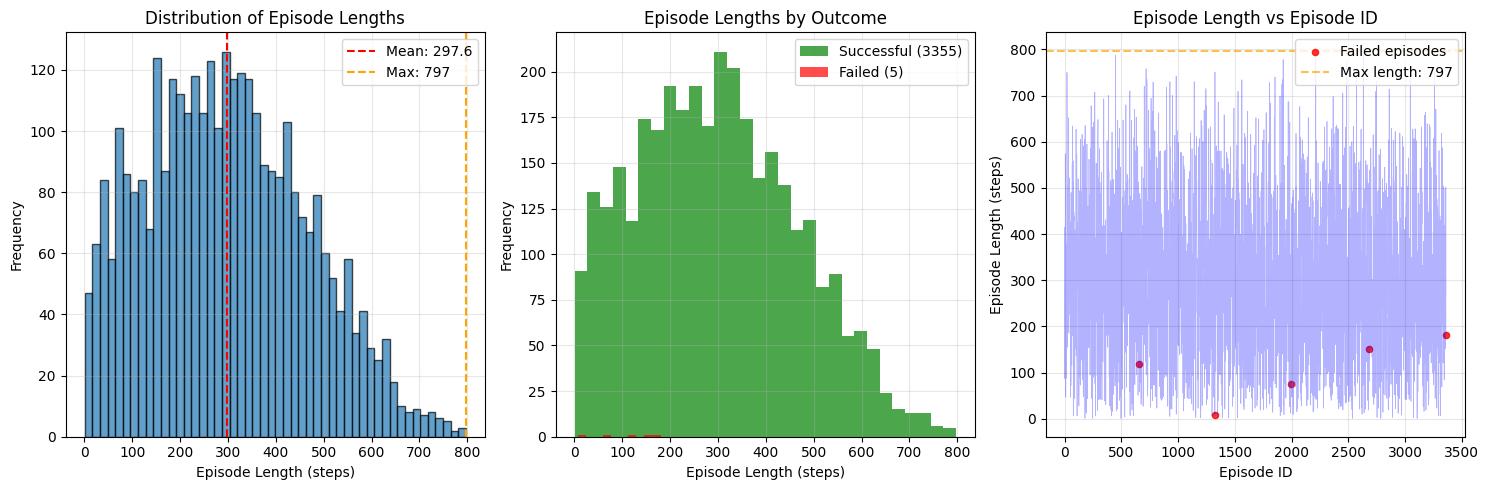


Conclusion:
- The environment appears to have max_episode_steps = 797
- Episodes reaching this limit are truncated
- 3355 episodes terminated successfully (goal reached)
- 5 episodes were likely truncated without reaching the goal


In [10]:
# Episode Termination and Length Analysis
import numpy as np
import matplotlib.pyplot as plt

print("EPISODE TERMINATION AND LENGTH ANALYSIS")
print("="*60)

print("Based on PointMaze Documentation:")
print("- Episode termination occurs in 2 ways:")
print("  1. TERMINATED: When goal is reached (Euclidean distance ≤ 0.5m)")
print("  2. TRUNCATED: When max_episode_steps is reached")
print("- Default max_episode_steps varies by maze size")
print("- Control frequency: 10 Hz")
print()

# Analyze episode lengths from our dataset
episode_lengths = []
episode_termination_info = []

print("Analyzing episode lengths from dataset...")

# Get episode length data (we already have some from action lengths)
if 'action_lengths' in globals():
    episode_lengths = action_lengths.copy()
    print("Using previously collected action_lengths as episode_lengths")
else:
    print("Collecting episode lengths...")
    for i, episode in enumerate(dataset.iterate_episodes()):
        episode_lengths.append(len(episode.actions))
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1}/{dataset.total_episodes} episodes...")

print(f"\nEpisode Length Statistics:")
print(f"- Total episodes: {len(episode_lengths)}")
print(f"- Min episode length: {min(episode_lengths)} steps")
print(f"- Max episode length: {max(episode_lengths)} steps")
print(f"- Mean episode length: {np.mean(episode_lengths):.2f} steps")
print(f"- Median episode length: {np.median(episode_lengths):.2f} steps")
print(f"- Std episode length: {np.std(episode_lengths):.2f} steps")

# Analyze correlation between episode length and success
successful_episodes_indices = [i for i, r in enumerate(episode_rewards) if r > 0]
failed_episodes_indices = [i for i, r in enumerate(episode_rewards) if r == 0]

successful_lengths = [episode_lengths[i] for i in successful_episodes_indices]
failed_lengths = [episode_lengths[i] for i in failed_episodes_indices]

print(f"\nSuccess vs Failure Analysis:")
print(f"- Successful episodes (reward=1): {len(successful_lengths)}")
print(f"  - Mean length: {np.mean(successful_lengths):.2f} steps")
print(f"  - Max length: {max(successful_lengths)} steps")
print(f"  - Min length: {min(successful_lengths)} steps")

if failed_lengths:
    print(f"- Failed episodes (reward=0): {len(failed_lengths)}")
    print(f"  - Mean length: {np.mean(failed_lengths):.2f} steps")
    print(f"  - Lengths: {failed_lengths}")

# Check if there's a maximum episode length (truncation limit)
max_length = max(episode_lengths)
episodes_at_max = [i for i, length in enumerate(episode_lengths) if length == max_length]

print(f"\nTruncation Analysis:")
print(f"- Maximum episode length observed: {max_length} steps")
print(f"- Episodes at maximum length: {len(episodes_at_max)}")
if len(episodes_at_max) > 0:
    print(f"- Episode indices at max length: {episodes_at_max[:10]}...")  # Show first 10
    # Check if these are successful or failed episodes
    max_length_rewards = [episode_rewards[i] for i in episodes_at_max]
    print(f"- Rewards for max-length episodes: {set(max_length_rewards)}")

# Time analysis (assuming 10 Hz control frequency)
control_freq = 10  # Hz
mean_time_seconds = np.mean(episode_lengths) / control_freq
max_time_seconds = max_length / control_freq

print(f"\nTime Analysis (at 10 Hz control frequency):")
print(f"- Mean episode duration: {mean_time_seconds:.2f} seconds")
print(f"- Maximum episode duration: {max_time_seconds:.2f} seconds")

# Plot episode length distribution
plt.figure(figsize=(15, 5))

# Plot 1: Histogram of episode lengths
plt.subplot(1, 3, 1)
plt.hist(episode_lengths, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(np.mean(episode_lengths), color='red', linestyle='--', 
           label=f'Mean: {np.mean(episode_lengths):.1f}')
plt.axvline(max_length, color='orange', linestyle='--', 
           label=f'Max: {max_length}')
plt.xlabel('Episode Length (steps)')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Lengths')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Success vs Failed episode lengths
plt.subplot(1, 3, 2)
if successful_lengths:
    plt.hist(successful_lengths, bins=30, alpha=0.7, 
             label=f'Successful ({len(successful_lengths)})', color='green')
if failed_lengths:
    plt.hist(failed_lengths, bins=10, alpha=0.7, 
             label=f'Failed ({len(failed_lengths)})', color='red')
plt.xlabel('Episode Length (steps)')
plt.ylabel('Frequency')
plt.title('Episode Lengths by Outcome')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Episode length vs Episode ID
plt.subplot(1, 3, 3)
plt.plot(range(len(episode_lengths)), episode_lengths, 'b-', alpha=0.3, linewidth=0.5)
# Highlight failed episodes
if failed_episodes_indices:
    failed_lengths_plot = [episode_lengths[i] for i in failed_episodes_indices]
    plt.scatter(failed_episodes_indices, failed_lengths_plot, 
               color='red', s=20, alpha=0.8, label='Failed episodes')
plt.axhline(max_length, color='orange', linestyle='--', alpha=0.7,
           label=f'Max length: {max_length}')
plt.xlabel('Episode ID')
plt.ylabel('Episode Length (steps)')
plt.title('Episode Length vs Episode ID')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusion:")
if len(episodes_at_max) > 0:
    print(f"- The environment appears to have max_episode_steps = {max_length}")
    print(f"- Episodes reaching this limit are truncated")
else:
    print(f"- No episodes reached a consistent maximum length")
    print(f"- Most episodes terminate when the goal is reached")

print(f"- {len(successful_lengths)} episodes terminated successfully (goal reached)")
print(f"- {len(failed_lengths)} episodes were likely truncated without reaching the goal")

ENVIRONMENT AND BOUNDARY ANALYSIS
ENVIRONMENTS IN USE:
1. Dataset: 'D4RL/pointmaze/large-v2' (Minari dataset)
2. Environment: 'PointMaze_Large-v3' (Gymnasium environment)

ENVIRONMENT DETAILS:
- Environment ID: PointMaze_Large-v3
- Environment type: <class 'gymnasium.wrappers.common.TimeLimit'>
- Unwrapped environment: <class 'gymnasium_robotics.envs.maze.point_maze.PointMazeEnv'>

MAZE CONFIGURATION:
- Maze type: <class 'gymnasium_robotics.envs.maze.maze_v4.Maze'>
- Maze size scaling: 1
- Maze map dimensions: 9 x 12 cells

MAZE MAP (1=wall, 0=free space):
Row  0: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Row  1: [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
Row  2: [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1]
Row  3: [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1]
Row  4: [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1]
Row  5: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1]
Row  6: [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1]
Row  7: [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
Row  8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

PHYSICAL BOUNDARIES:
- Cell siz

TypeError: list indices must be integers or slices, not tuple

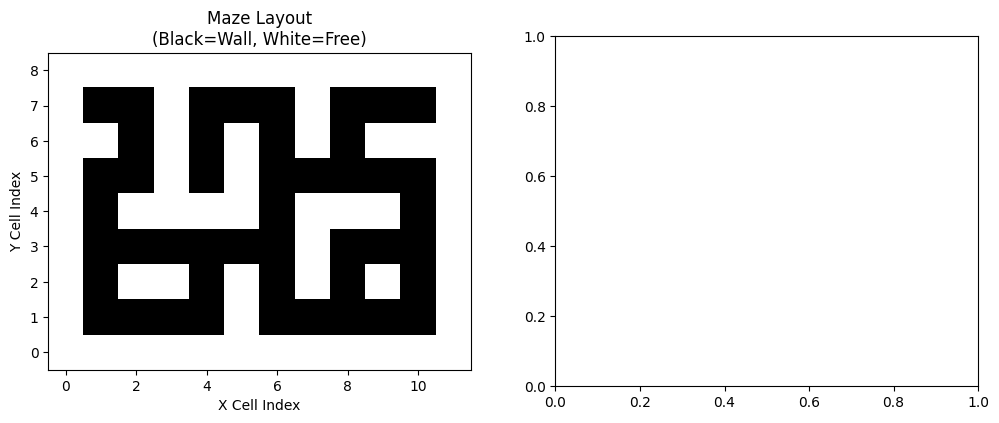

In [12]:
# Environment and Boundary Analysis
import numpy as np
import matplotlib.pyplot as plt

print("ENVIRONMENT AND BOUNDARY ANALYSIS")
print("="*50)

print("ENVIRONMENTS IN USE:")
print("1. Dataset: 'D4RL/pointmaze/large-v2' (Minari dataset)")
print("2. Environment: 'PointMaze_Large-v3' (Gymnasium environment)")
print()

# Environment details
print("ENVIRONMENT DETAILS:")
print(f"- Environment ID: {env.spec.id}")
print(f"- Environment type: {type(env)}")
print(f"- Unwrapped environment: {type(env.unwrapped)}")

# Get maze information
unwrapped_env = env.unwrapped
maze = unwrapped_env.maze

print(f"\nMAZE CONFIGURATION:")
print(f"- Maze type: {type(maze)}")
print(f"- Maze size scaling: {maze.maze_size_scaling}")

# Get the maze map
maze_map = maze.maze_map
print(f"- Maze map dimensions: {len(maze_map)} x {len(maze_map[0])} cells")

print(f"\nMAZE MAP (1=wall, 0=free space):")
for i, row in enumerate(maze_map):
    print(f"Row {i:2d}: {row}")

# Calculate physical boundaries
rows, cols = len(maze_map), len(maze_map[0])
cell_size = maze.maze_size_scaling  # Each cell is this size in meters

print(f"\nPHYSICAL BOUNDARIES:")
print(f"- Cell size: {cell_size} meters")
print(f"- Maze grid size: {rows} x {cols} cells")

# Get goal and reset locations
goal_locations = maze.unique_goal_locations
reset_locations = maze.unique_reset_locations

print(f"- Number of unique goal locations: {len(goal_locations)}")
print(f"- Number of unique reset locations: {len(reset_locations)}")

# Find actual boundaries from these locations
all_positions = np.vstack([goal_locations, reset_locations])
actual_x_min, actual_x_max = all_positions[:, 0].min(), all_positions[:, 0].max()
actual_y_min, actual_y_max = all_positions[:, 1].min(), all_positions[:, 1].max()

print(f"- Actual X range (from goal/reset positions): [{actual_x_min:.3f}, {actual_x_max:.3f}]")
print(f"- Actual Y range (from goal/reset positions): [{actual_y_min:.3f}, {actual_y_max:.3f}]")

# Add noise range to get full possible range
noise_range = unwrapped_env.position_noise_range
print(f"- Position noise range: ±{noise_range}")
print(f"- Full possible X range: [{actual_x_min-noise_range:.3f}, {actual_x_max+noise_range:.3f}]")
print(f"- Full possible Y range: [{actual_y_min-noise_range:.3f}, {actual_y_max+noise_range:.3f}]")

# Let's check the dataset boundaries by looking at a few episodes
print(f"\nDATASET POSITION ANALYSIS:")
print("Analyzing positions from first few episodes...")

dataset_positions = []
try:
    for i, episode in enumerate(dataset.iterate_episodes()):
        if i >= 5:  # Just check first 5 episodes for speed
            break
        
        # The observations in Minari dataset are structured differently
        # Let's look at the structure first
        if i == 0:
            print(f"Episode {i} observation structure:")
            print(f"- Type: {type(episode.observations)}")
            print(f"- Shape: {episode.observations.shape if hasattr(episode.observations, 'shape') else 'No shape'}")
            if len(episode.observations) > 0:
                print(f"- First obs type: {type(episode.observations[0])}")
                print(f"- First obs keys: {episode.observations[0].keys() if hasattr(episode.observations[0], 'keys') else 'No keys'}")
        
        # Extract achieved_goal positions
        for obs in episode.observations:
            if hasattr(obs, 'keys') and 'achieved_goal' in obs:
                dataset_positions.append(obs['achieved_goal'])
            elif isinstance(obs, dict) and 'achieved_goal' in obs:
                dataset_positions.append(obs['achieved_goal'])
                
except Exception as e:
    print(f"Error analyzing dataset positions: {e}")

if dataset_positions:
    dataset_positions = np.array(dataset_positions)
    dataset_x_min, dataset_x_max = dataset_positions[:, 0].min(), dataset_positions[:, 0].max()
    dataset_y_min, dataset_y_max = dataset_positions[:, 1].min(), dataset_positions[:, 1].max()
    
    print(f"- Dataset X range (from sample episodes): [{dataset_x_min:.3f}, {dataset_x_max:.3f}]")
    print(f"- Dataset Y range (from sample episodes): [{dataset_y_min:.3f}, {dataset_y_max:.3f}]")
else:
    print("- Could not extract positions from dataset (different format)")

# Visualize the maze
plt.figure(figsize=(12, 10))

# Plot maze map
maze_array = np.array(maze_map, dtype=float)
plt.subplot(2, 2, 1)
plt.imshow(maze_array, cmap='gray', origin='lower')
plt.title('Maze Layout\n(Black=Wall, White=Free)')
plt.xlabel('X Cell Index')
plt.ylabel('Y Cell Index')

# Plot goal and reset locations
plt.subplot(2, 2, 2)
goal_x, goal_y = goal_locations[:, 0], goal_locations[:, 1]
reset_x, reset_y = reset_locations[:, 0], reset_locations[:, 1]

plt.scatter(goal_x, goal_y, c='red', marker='*', s=100, alpha=0.8, label='Goal Locations')
plt.scatter(reset_x, reset_y, c='blue', marker='s', s=80, alpha=0.8, label='Reset Locations')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.title('Goal and Reset Locations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot with boundaries
plt.subplot(2, 2, 3)
plt.scatter(goal_x, goal_y, c='red', marker='*', s=100, alpha=0.8, label='Goals')
plt.scatter(reset_x, reset_y, c='blue', marker='s', s=80, alpha=0.8, label='Resets')

# Add boundary lines
plt.axvline(actual_x_min, color='green', linestyle='--', alpha=0.7, label='X Boundaries')
plt.axvline(actual_x_max, color='green', linestyle='--', alpha=0.7)
plt.axhline(actual_y_min, color='orange', linestyle='--', alpha=0.7, label='Y Boundaries')
plt.axhline(actual_y_max, color='orange', linestyle='--', alpha=0.7)

plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.title('Positions with Boundaries')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Show dataset positions if available
if dataset_positions:
    plt.subplot(2, 2, 4)
    plt.scatter(dataset_positions[:, 0], dataset_positions[:, 1], 
               c='purple', alpha=0.1, s=1, label='Agent Positions (Sample)')
    plt.xlabel('X Position (meters)')
    plt.ylabel('Y Position (meters)')
    plt.title('Sample Agent Positions\n(First Few Episodes)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSUMMARY:")
print(f"Environment: PointMaze_Large-v3")
print(f"Maze size: {rows}x{cols} cells, {cell_size}m per cell")
print(f"Physical boundaries:")
print(f"  X: [{actual_x_min-noise_range:.2f}, {actual_x_max+noise_range:.2f}] meters")
print(f"  Y: [{actual_y_min-noise_range:.2f}, {actual_y_max+noise_range:.2f}] meters")